# NFL Big Data Bowl — Initial Data Overview

**Focus:** pass protection and pass rush  
**Audience:** coaches, scouts, and football analysts  
**Data:** Weeks 1–8 of the 2021 NFL season

This notebook establishes what the dataset contains, checks its quality, and develops an initial football-facing view of the pass-rush/pass-protection problem. Each chart is followed by a short interpretation in plain language.

### Questions we will answer
1. How much data is available, and how do the files connect?
2. What situations and outcomes are represented?
3. What do the PFF scouting labels tell us about pressure?
4. What does one tracked play look like?
5. Which initial metrics could become useful coaching and scouting tools?

## 1. Setup

The summary tables are small enough to load together. Tracking data is much larger, so we inventory all tracking files but load only one game for the first visual analysis.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (10, 5), "axes.titleweight": "bold"})
pd.set_option("display.max_columns", 50)

In [2]:
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "nfl-big-data-bowl-regional-event-data" / "data"

# Also works if Jupyter starts inside a notebooks/ directory later.
if not DATA_DIR.exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
    DATA_DIR = PROJECT_ROOT / "nfl-big-data-bowl-regional-event-data" / "data"

TRACKING_DIR = DATA_DIR / "tracking"
assert DATA_DIR.exists(), f"Data folder not found: {DATA_DIR}"
print(f"Using data from: {DATA_DIR}")

Using data from: /Users/billchu/Desktop/NFL AWS Big Data Bowl/nfl-big-data-bowl-regional-event-data/data


In [3]:
games = pd.read_csv(DATA_DIR / "games.csv")
plays = pd.read_csv(DATA_DIR / "plays.csv")
players = pd.read_csv(DATA_DIR / "players.csv")
pff = pd.read_csv(DATA_DIR / "pffScoutingData.csv")

## 2. Dataset inventory

The tables operate at different levels:

| Table | One row represents | Join key |
|---|---|---|
| `games` | One NFL game | `gameId` |
| `plays` | One passing play/dropback | `gameId`, `playId` |
| `players` | One player | `nflId` |
| `pffScoutingData` | One player's role on one play | `gameId`, `playId`, `nflId` |
| `tracking_*` | One player or football at one 0.1-second frame | `gameId`, `playId`, `nflId`, `frameId` |

In [4]:
summary_tables = {
    "Games": games,
    "Plays": plays,
    "Players": players,
    "PFF scouting": pff,
}

inventory = pd.DataFrame([
    {"Table": name, "Rows": f"{len(df):,}", "Columns": df.shape[1]}
    for name, df in summary_tables.items()
])
inventory

,Table,Rows,Columns
0,Games,122,7
1,Plays,"8,557",32
2,Players,"1,679",7
3,PFF scouting,"188,254",15


In [5]:
tracking_files = sorted(TRACKING_DIR.glob("tracking_*.csv"))
tracking_size_gb = sum(path.stat().st_size for path in tracking_files) / 1024**3

pd.DataFrame({
    "Tracking files (one per game)": [len(tracking_files)],
    "Approximate size on disk (GB)": [round(tracking_size_gb, 2)],
    "Sampling frequency": ["10 frames per second"],
})

,Tracking files (one per game),Approximate size on disk (GB),Sampling frequency
0,122,0.79,10 frames per second


**Football interpretation:** the dataset is deep rather than merely broad. It contains thousands of pass plays, but the main analytical value comes from repeatedly observing all 22 players and the football during every play. That allows us to measure *how* a rep developed—not only its final box-score result.

## 3. Coverage and basic data quality

In [5]:
coverage = pd.Series({
    "Season": int(games["season"].min()),
    "Weeks": f"{games['week'].min()}–{games['week'].max()}",
    "Games": games["gameId"].nunique(),
    "Dropbacks / plays": len(plays),
    "Players": players["nflId"].nunique(),
    "Teams represented": len(set(games["homeTeamAbbr"]) | set(games["visitorTeamAbbr"])),
})
coverage.to_frame("Value")

,Value
Season,2021
Weeks,1–8
Games,122
Dropbacks / plays,8557
Players,1679
Teams represented,32


In [6]:
key_checks = pd.DataFrame({
    "Check": [
        "gameId is unique in games",
        "(gameId, playId) is unique in plays",
        "nflId is unique in players",
        "PFF player-play keys are unique",
    ],
    "Passed": [
        games["gameId"].is_unique,
        not plays.duplicated(["gameId", "playId"]).any(),
        players["nflId"].is_unique,
        not pff.duplicated(["gameId", "playId", "nflId"]).any(),
    ],
})
key_checks

,Check,Passed
0,gameId is unique in games,True
1,"(gameId, playId) is unique in plays",True
2,nflId is unique in players,True
3,PFF player-play keys are unique,True


In [7]:
analysis_fields = [
    "down", "yardsToGo", "offenseFormation", "personnelO",
    "defendersInBox", "dropBackType", "pff_playAction",
    "pff_passCoverage", "pff_passCoverageType", "passResult",
]

field_quality = pd.DataFrame({
    "Missing rows": plays[analysis_fields].isna().sum(),
    "Missing %": plays[analysis_fields].isna().mean().mul(100).round(2),
}).sort_values("Missing %", ascending=False)
field_quality

,Missing rows,Missing %
dropBackType,528,6.17
offenseFormation,7,0.08
defendersInBox,7,0.08
personnelO,1,0.01
down,0,0.00
yardsToGo,0,0.00
pff_playAction,0,0.00
pff_passCoverage,0,0.00
pff_passCoverageType,0,0.00
passResult,0,0.00


**Data-quality note:** missing PFF values must be interpreted by role. For example, `pff_sackAllowed` is expected to be empty for a pass rusher because that field only applies to blockers. We should filter to the relevant role before evaluating these fields rather than treating every empty value as bad data.

### A quick look at the football context available on each play

In [9]:
play_columns = [
    "gameId", "playId", "down", "yardsToGo",
    "offenseFormation", "personnelO", "defendersInBox",
    "pff_passCoverage", "passResult", "playResult",
]
plays[play_columns].head()

,gameId,playId,down,yardsToGo,offenseFormation,personnelO,defendersInBox,pff_passCoverage,passResult,playResult
0,2021090900,97,3,2,SHOTGUN,"1 RB, 1 TE, 3 WR",6.0,Cover-1,I,0
1,2021090900,137,1,10,EMPTY,"1 RB, 2 TE, 2 WR",6.0,Cover-3,C,28
2,2021090900,187,2,6,SHOTGUN,"0 RB, 2 TE, 3 WR",6.0,Cover-3,C,5
3,2021090900,282,1,10,SINGLEBACK,"1 RB, 2 TE, 2 WR",6.0,Cover-3,I,0
4,2021090900,349,3,15,SHOTGUN,"1 RB, 1 TE, 3 WR",7.0,Cover-3,I,0


## 4. What situations are represented?

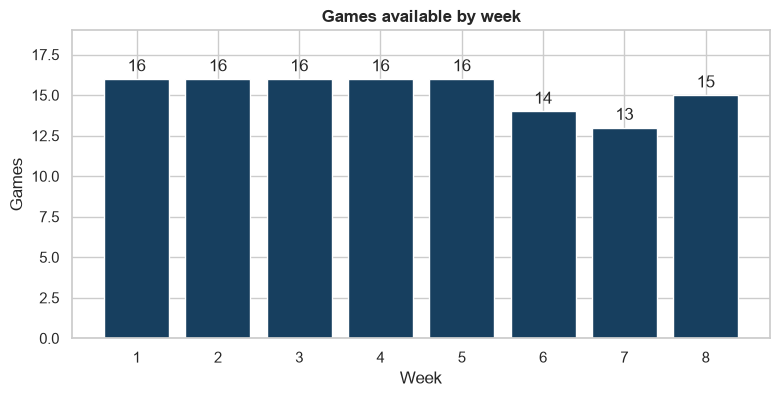

In [10]:
games_by_week = games["week"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(games_by_week.index, games_by_week.values, color="#173F5F")
ax.bar_label(bars, padding=3)
ax.set(title="Games available by week", xlabel="Week", ylabel="Games")
ax.set_ylim(0, games_by_week.max() + 3)
plt.show()

**What this means:** this is an eight-week sample, not a full season. It is large enough for an initial model, but player rankings should use minimum-rep filters and uncertainty ranges—especially for rotational players or players who missed games.

### 4.1 Dropback outcomes

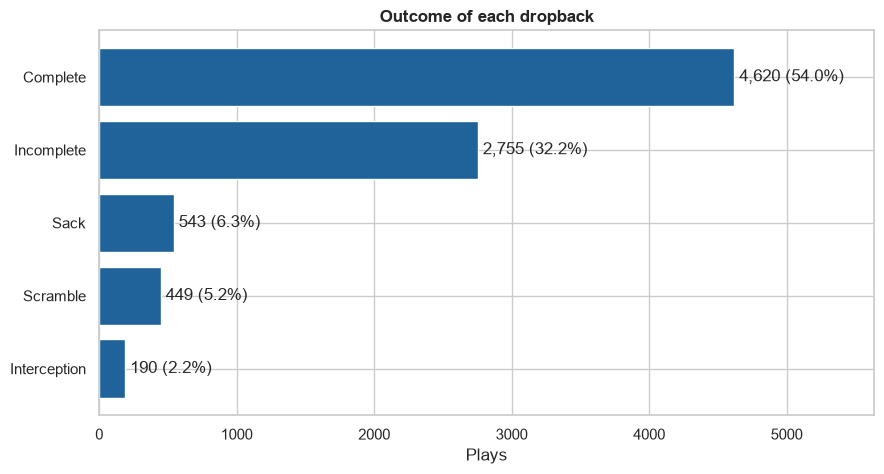

In [11]:
result_names = {
    "C": "Complete", "I": "Incomplete", "S": "Sack",
    "R": "Scramble", "IN": "Interception",
}
result_order = ["Complete", "Incomplete", "Sack", "Scramble", "Interception"]
outcomes = plays["passResult"].map(result_names).value_counts().reindex(result_order)

fig, ax = plt.subplots()
bars = ax.barh(outcomes.index, outcomes.values, color="#20639B")
ax.invert_yaxis()
ax.set(title="Outcome of each dropback", xlabel="Plays", ylabel="")
for bar, count in zip(bars, outcomes):
    ax.text(count + 35, bar.get_y() + bar.get_height() / 2,
            f"{count:,} ({count / len(plays):.1%})", va="center")
ax.set_xlim(0, outcomes.max() * 1.22)
plt.show()

**Coach/scout takeaway:** sacks occur on only a small share of dropbacks. A sack-only evaluation will miss reps where a defender wins quickly but the quarterback gets the ball out, as well as reps where protection fails without producing a sack. Pressure and timing are more informative than the final result alone.

### 4.2 Down and offensive formation

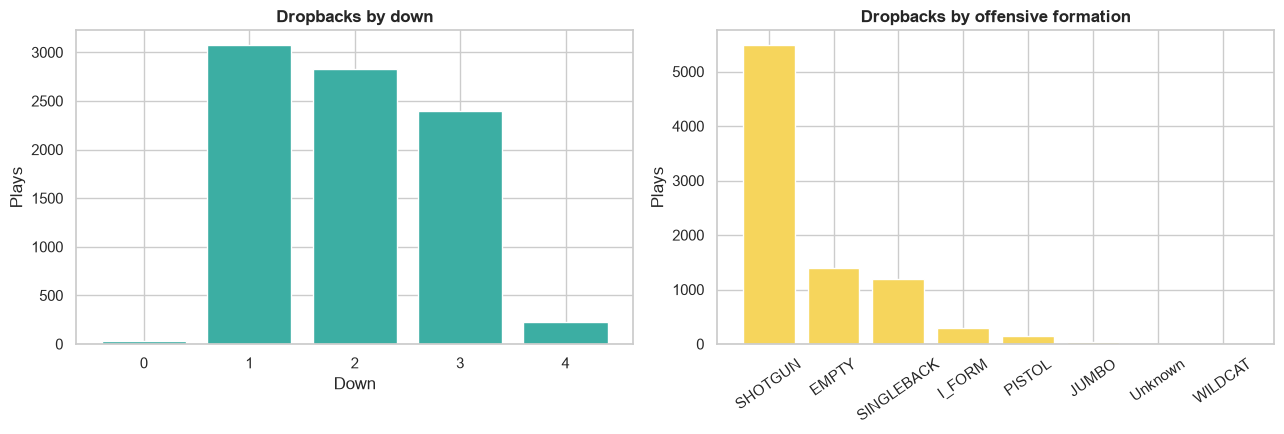

In [12]:
down_counts = plays["down"].value_counts().sort_index()
formation_counts = plays["offenseFormation"].fillna("Unknown").value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(down_counts.index.astype(str), down_counts.values, color="#3CAEA3")
axes[0].set(title="Dropbacks by down", xlabel="Down", ylabel="Plays")
axes[1].bar(formation_counts.index, formation_counts.values, color="#F6D55C")
axes[1].set(title="Dropbacks by offensive formation", xlabel="", ylabel="Plays")
axes[1].tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

**What this means:** Shotgun and Empty create a different protection picture than under-center formations. A fair player metric should compare similar assignments and should account for formation, play action, number of blockers, and likely time to throw.

### 4.3 Defensive coverage

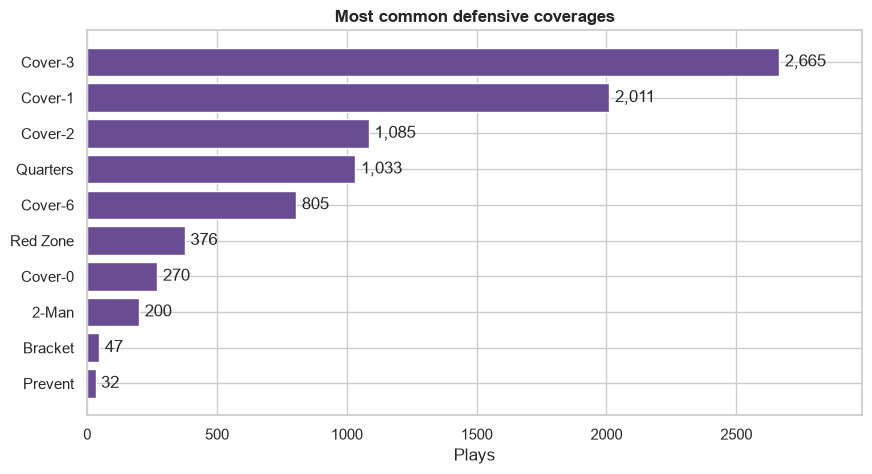

In [13]:
coverage_counts = plays["pff_passCoverage"].fillna("Unknown").value_counts().head(10)

fig, ax = plt.subplots()
bars = ax.barh(coverage_counts.index, coverage_counts.values, color="#6A4C93")
ax.invert_yaxis()
ax.bar_label(bars, padding=4, fmt="{:,.0f}")
ax.set(title="Most common defensive coverages", xlabel="Plays", ylabel="")
ax.set_xlim(0, coverage_counts.max() * 1.12)
plt.show()

**What this means:** coverage changes the quarterback's read and expected holding time. The line may protect well for 2.5 seconds and still allow late pressure on a long-developing concept. A context-adjusted metric should separate early losses from pressure created only after extended time.

## 5. PFF scouting labels: the matchup and the result

PFF assigns a role to every player on each play. For blockers, `pff_nflIdBlockedPlayer` identifies the first defender blocked. These labels provide a useful benchmark for validating a tracking-based metric.

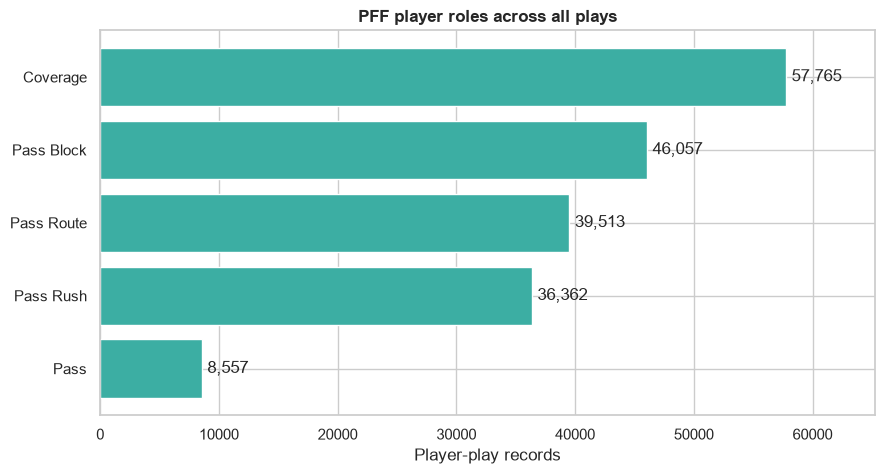

In [14]:
role_counts = pff["pff_role"].value_counts()

fig, ax = plt.subplots()
bars = ax.barh(role_counts.index, role_counts.values, color="#3CAEA3")
ax.invert_yaxis()
ax.bar_label(bars, padding=4, fmt="{:,.0f}")
ax.set(title="PFF player roles across all plays", xlabel="Player-play records", ylabel="")
ax.set_xlim(0, role_counts.max() * 1.13)
plt.show()

### 5.1 How often are rushers credited with pressure?

We define a simple descriptive **pressure flag** as any PFF sack, hit, or hurry. This is only a baseline—it does not yet account for the assignment, double teams, quarterback movement, or time to throw.

In [15]:
pressure_columns = ["pff_sack", "pff_hit", "pff_hurry"]
rushers = pff.loc[pff["pff_role"].eq("Pass Rush")].copy()
rushers[pressure_columns] = rushers[pressure_columns].fillna(0)
rushers["pressure"] = rushers[pressure_columns].max(axis=1)

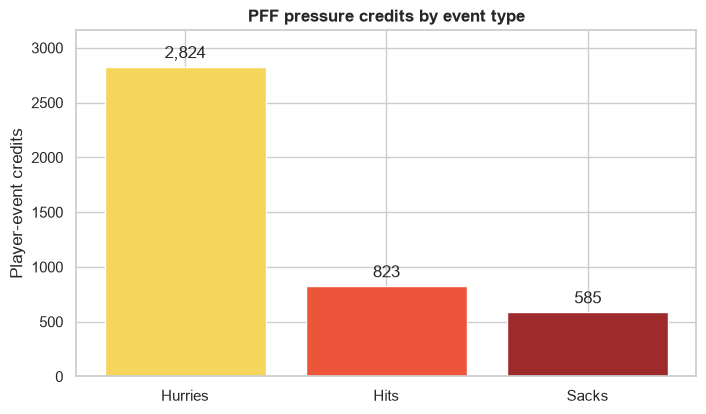

In [16]:
pressure_credits = rushers[["pff_hurry", "pff_hit", "pff_sack"]].sum()
pressure_credits.index = ["Hurries", "Hits", "Sacks"]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(pressure_credits.index, pressure_credits.values,
              color=["#F6D55C", "#ED553B", "#9E2A2B"])
ax.bar_label(bars, padding=4, fmt="{:,.0f}")
ax.set(title="PFF pressure credits by event type", ylabel="Player-event credits")
ax.set_ylim(0, pressure_credits.max() * 1.12)
plt.show()

**Coach/scout takeaway:** hurries are much more frequent than sacks and carry important information about rep quality. They should be included in the evaluation, but a binary pressure flag still treats an instant win and a late cleanup pressure as equal. Tracking time can separate those cases.

### 5.2 Team-level pressure by down

The next chart marks a play as pressured when at least one pass rusher received a PFF pressure credit.

In [17]:
play_pressure = (
    rushers.groupby(["gameId", "playId"], as_index=False)
    .agg(pressured=("pressure", "max"))
)
play_context = plays.merge(play_pressure, on=["gameId", "playId"], how="left")
play_context["pressured"] = play_context["pressured"].fillna(0)

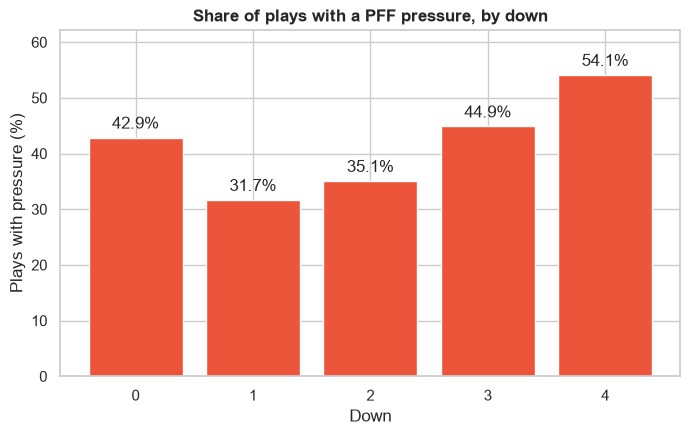

In [18]:
pressure_by_down = (
    play_context.groupby("down")["pressured"]
    .agg(["mean", "size"])
    .rename(columns={"mean": "pressure_rate", "size": "plays"})
)

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(pressure_by_down.index.astype(str),
              pressure_by_down["pressure_rate"] * 100, color="#ED553B")
ax.bar_label(bars, labels=[f"{value:.1%}" for value in pressure_by_down["pressure_rate"]], padding=4)
ax.set(title="Share of plays with a PFF pressure, by down",
       xlabel="Down", ylabel="Plays with pressure (%)")
ax.set_ylim(0, pressure_by_down["pressure_rate"].max() * 115)
plt.show()

**What this means:** pressure opportunity is situational. Obvious passing downs can allow defenders to attack differently, while screens, play action, and quick game alter the job. Individual comparisons should be adjusted for the situations each player faced.

## 6. Descriptive player baselines (not final grades)

These leaderboards illustrate what the PFF outcomes alone can produce. They use a **100-rep minimum** to reduce small-sample noise. They are benchmarks for a future tracking metric—not definitive rankings.

In [19]:
player_names = players.set_index("nflId")["displayName"]

rusher_summary = (
    rushers.groupby("nflId")
    .agg(rush_reps=("pressure", "size"), pressures=("pressure", "sum"),
         sacks=("pff_sack", "sum"))
    .assign(pressure_rate=lambda df: df["pressures"] / df["rush_reps"])
    .reset_index()
)
rusher_summary["player"] = rusher_summary["nflId"].map(player_names)

top_rushers = (rusher_summary.query("rush_reps >= 100")
               .nlargest(10, "pressure_rate")
               .sort_values("pressure_rate"))

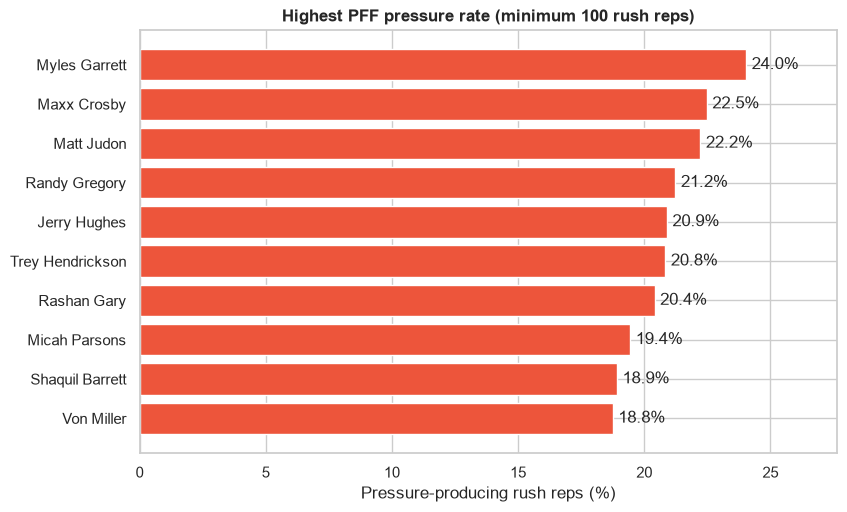

In [20]:
fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(top_rushers["player"], top_rushers["pressure_rate"] * 100, color="#ED553B")
ax.bar_label(bars, labels=[f"{rate:.1%}" for rate in top_rushers["pressure_rate"]], padding=4)
ax.set(title="Highest PFF pressure rate (minimum 100 rush reps)",
       xlabel="Pressure-producing rush reps (%)", ylabel="")
ax.set_xlim(0, top_rushers["pressure_rate"].max() * 115)
plt.show()

### 6.1 Blocker baseline: pressure allowed

In [21]:
allowed_columns = ["pff_sackAllowed", "pff_hitAllowed", "pff_hurryAllowed"]
blockers = pff.loc[pff["pff_role"].eq("Pass Block")].copy()
blockers[allowed_columns] = blockers[allowed_columns].fillna(0)
blockers["pressure_allowed"] = blockers[allowed_columns].max(axis=1)

blocker_summary = (
    blockers.groupby("nflId")
    .agg(block_reps=("pressure_allowed", "size"), allowed=("pressure_allowed", "sum"))
    .assign(allowed_rate=lambda df: df["allowed"] / df["block_reps"])
    .reset_index()
)
blocker_summary["player"] = blocker_summary["nflId"].map(player_names)

best_blockers = (blocker_summary.query("block_reps >= 100")
                 .nsmallest(10, "allowed_rate")
                 .sort_values("allowed_rate", ascending=False))

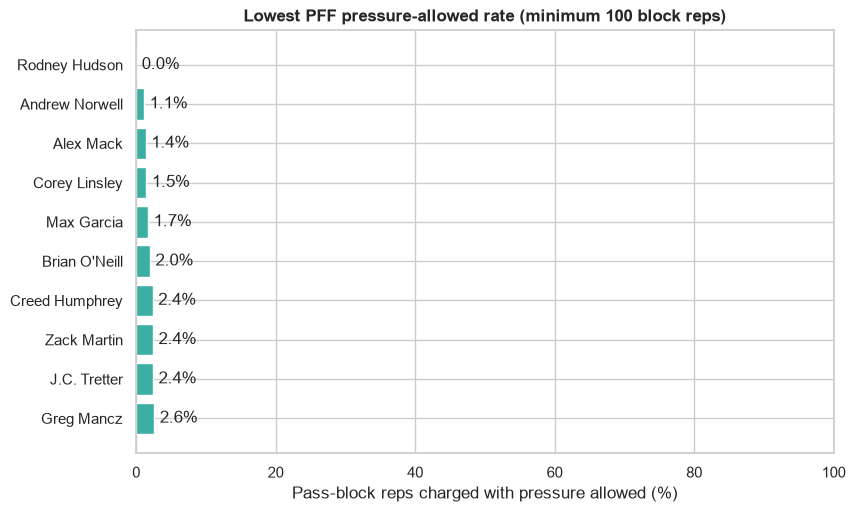

In [22]:
fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(best_blockers["player"], best_blockers["allowed_rate"] * 100, color="#3CAEA3")
ax.bar_label(bars, labels=[f"{rate:.1%}" for rate in best_blockers["allowed_rate"]], padding=4)
ax.set(title="Lowest PFF pressure-allowed rate (minimum 100 block reps)",
       xlabel="Pass-block reps charged with pressure allowed (%)", ylabel="")
ax.set_xlim(0, max(best_blockers["allowed_rate"].max() * 1.25, 1) * 100)
plt.show()

**Important caveat:** these charts describe credited outcomes, not total rep quality. They do not yet distinguish a clean one-on-one win from help protection, account for quarterback movement, or reward a blocker who holds up long enough before late pressure. Those limitations motivate a tracking-based metric.

## 7. Tracking data: inspect one sack play

We now load one game's tracking file and select one sack. This keeps the first notebook responsive while showing the structure that will power the metric.

In [23]:
GAME_ID = int(games.sort_values(["week", "gameId"]).iloc[0]["gameId"])
tracking = pd.read_csv(TRACKING_DIR / f"tracking_{GAME_ID}.csv")

print(f"Game {GAME_ID}: {len(tracking):,} tracking rows")
print(f"Tracked plays: {tracking['playId'].nunique():,}")
tracking.head(3)

Game 2021090900: 92,644 tracking rows
Tracked plays: 97


,gameId,playId,nflId,frameId,time,jerseyNumber,team,playDirection,x,y,s,a,dis,o,dir,event
0,2021090900,97,25511.0,1,2021-09-10T00:26:31Z,12.0,TB,right,37.77,24.22,0.29,0.30,0.03,165.16,84.99,NaN
1,2021090900,97,25511.0,2,2021-09-10T00:26:31Z,12.0,TB,right,37.78,24.22,0.23,0.11,0.02,164.33,92.87,NaN
2,2021090900,97,25511.0,3,2021-09-10T00:26:31Z,12.0,TB,right,37.78,24.24,0.16,0.10,0.01,160.24,68.55,NaN


In [24]:
sack_plays = plays.loc[
    plays["gameId"].eq(GAME_ID) & plays["passResult"].eq("S"), "playId"
]
PLAY_ID = int(sack_plays.iloc[0])
play_info = plays.loc[
    plays["gameId"].eq(GAME_ID) & plays["playId"].eq(PLAY_ID)
].iloc[0]
play_tracking = tracking.loc[tracking["playId"].eq(PLAY_ID)].copy()

play_info[["playDescription", "down", "yardsToGo", "offenseFormation",
           "possessionTeam", "defensiveTeam", "pff_passCoverage"]].to_frame("Value")

,Value
playDescription,(1:11) (Shotgun) D.Prescott sacked at TB 33 fo...
down,2
yardsToGo,10
offenseFormation,SHOTGUN
possessionTeam,DAL
defensiveTeam,TB
pff_passCoverage,Quarters


### 7.1 Event tags define the timing of the play

In [25]:
event_timeline = (
    play_tracking.loc[play_tracking["event"].ne("None"), ["event", "frameId"]]
    .drop_duplicates()
    .sort_values("frameId")
    .reset_index(drop=True)
)
event_timeline

,event,frameId
0,NaN,1
1,NaN,2
2,NaN,3
3,NaN,4
4,NaN,5
...,...,...
59,NaN,60
60,NaN,61
61,NaN,62
62,NaN,63


**Why it matters:** `ball_snap`, `pass_forward`, and `qb_sack` establish a football clock for each rep. We can report intuitive quantities such as “won in 1.8 seconds” or “maintained the block through 2.7 seconds.”

### 7.2 Player alignment at the snap

In [26]:
snap_rows = play_tracking.loc[play_tracking["event"].eq("ball_snap")]
snap_frame = int(snap_rows["frameId"].min())
snap = play_tracking.loc[play_tracking["frameId"].eq(snap_frame)]

offense = play_info["possessionTeam"]
defense = play_info["defensiveTeam"]
print(f"Snap frame: {snap_frame} | offense: {offense} | defense: {defense}")

Snap frame: 6 | offense: DAL | defense: TB


In [27]:
def format_field(ax):
    """Apply a simple NFL field background."""
    ax.set(xlim=(0, 120), ylim=(0, 53.3), xlabel="Field length (yards)",
           ylabel="Field width (yards)")
    ax.set_facecolor("#E8F3E8")
    for yard in range(10, 111, 10):
        ax.axvline(yard, color="white", linewidth=1, alpha=0.9)
    ax.axvline(play_info["absoluteYardlineNumber"], color="#F6D55C",
               linestyle="--", linewidth=2, label="Line of scrimmage")

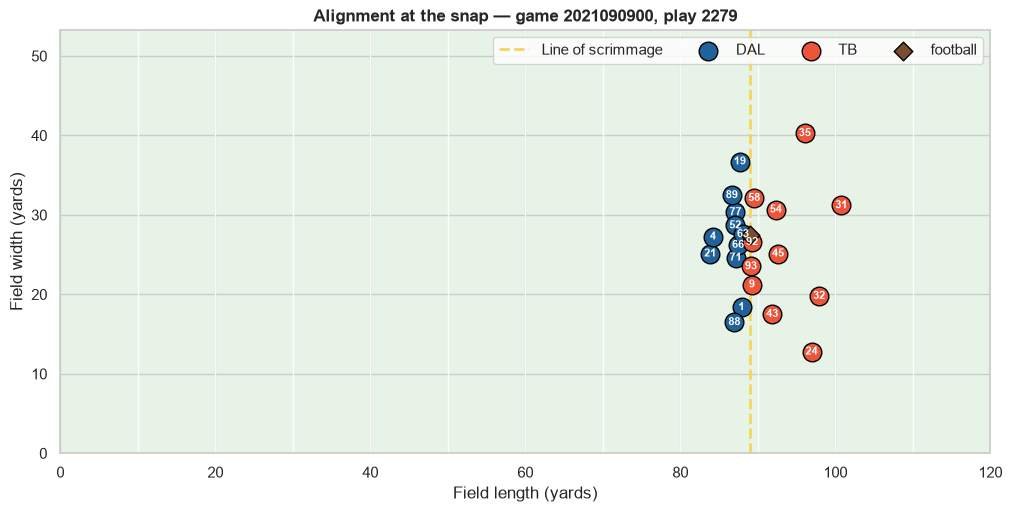

In [28]:
fig, ax = plt.subplots(figsize=(12, 5.5))
format_field(ax)
team_colors = {offense: "#20639B", defense: "#ED553B", "football": "#7A4E2D"}

for team, group in snap.groupby("team"):
    marker = "D" if team == "football" else "o"
    size = 90 if team == "football" else 180
    ax.scatter(group["x"], group["y"], s=size, marker=marker,
               color=team_colors.get(team, "gray"), edgecolor="black", label=team, zorder=3)
    for row in group.dropna(subset=["jerseyNumber"]).itertuples():
        ax.text(row.x, row.y, str(int(row.jerseyNumber)), ha="center", va="center",
                color="white", fontsize=8, fontweight="bold", zorder=4)

ax.set_title(f"Alignment at the snap — game {GAME_ID}, play {PLAY_ID}")
ax.legend(loc="upper right", ncols=4)
plt.show()

**How to read it:** blue is the offense, red is the defense, and the dashed line is the line of scrimmage. The tracking file gives us every player's leverage, alignment, speed, and movement—not just the players eventually credited with the result.

### 7.3 PFF blocker–rusher assignments for the selected play

In [29]:
play_pff = pff.loc[pff["gameId"].eq(GAME_ID) & pff["playId"].eq(PLAY_ID)]
pairings = play_pff.loc[
    play_pff["pff_role"].eq("Pass Block") & play_pff["pff_nflIdBlockedPlayer"].notna(),
    ["nflId", "pff_positionLinedUp", "pff_nflIdBlockedPlayer", "pff_blockType"]
].copy()
pairings["Blocker"] = pairings["nflId"].map(player_names)
pairings["Primary rusher"] = pairings["pff_nflIdBlockedPlayer"].map(player_names)
pairings[["Blocker", "pff_positionLinedUp", "Primary rusher", "pff_blockType"]]


,Blocker,pff_positionLinedUp,Primary rusher,pff_blockType
947,Tyron Smith,LT,Shaquil Barrett,PP
953,La'el Collins,RT,Ndamukong Suh,PP
957,Connor Williams,LG,Shaquil Barrett,CL
961,Connor McGovern,RG,Ndamukong Suh,SW
966,Tyler Biadasz,C,William Gholston,PP


### 7.4 How quickly does each rusher close on the quarterback?

Distance to the quarterback is not a complete pass-rush grade, but it is an intuitive first tracking signal.

In [30]:
qb_id = int(play_pff.loc[play_pff["pff_role"].eq("Pass"), "nflId"].iloc[0])
rusher_ids = play_pff.loc[play_pff["pff_role"].eq("Pass Rush"), "nflId"]

end_candidates = play_tracking.loc[
    play_tracking["event"].isin(["qb_sack", "pass_forward", "autoevent_passforward"]), "frameId"
]
end_frame = int(end_candidates[end_candidates >= snap_frame].min())
segment = play_tracking.loc[play_tracking["frameId"].between(snap_frame, end_frame)]

In [31]:
qb_xy = (segment.loc[segment["nflId"].eq(qb_id), ["frameId", "x", "y"]]
         .rename(columns={"x": "qb_x", "y": "qb_y"}))
rush_xy = segment.loc[segment["nflId"].isin(rusher_ids)].merge(qb_xy, on="frameId")

rush_xy["distance_to_qb"] = np.hypot(rush_xy["x"] - rush_xy["qb_x"],
                                        rush_xy["y"] - rush_xy["qb_y"])
rush_xy["seconds_after_snap"] = (rush_xy["frameId"] - snap_frame) / 10
rush_xy["rusher"] = rush_xy["nflId"].map(player_names)

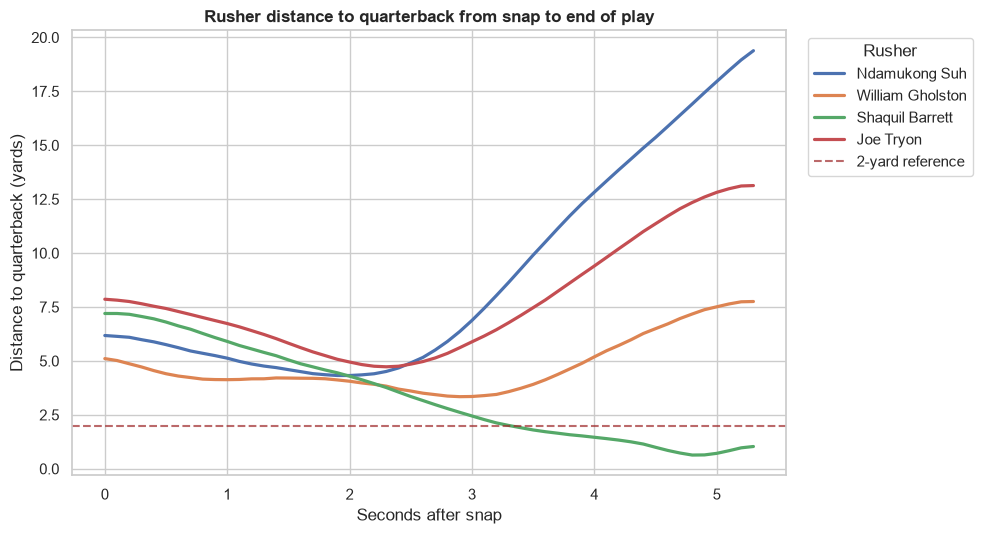

In [32]:
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.lineplot(data=rush_xy, x="seconds_after_snap", y="distance_to_qb",
             hue="rusher", linewidth=2.3, ax=ax)
ax.axhline(2, color="#9E2A2B", linestyle="--", alpha=0.7, label="2-yard reference")
ax.set(title="Rusher distance to quarterback from snap to end of play",
       xlabel="Seconds after snap", ylabel="Distance to quarterback (yards)")
ax.legend(title="Rusher", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Coach/scout takeaway:** this view shows *when* the pocket became threatened and which defender closed fastest. A stronger metric will add the assigned blocker, rusher angle, quarterback movement, and available path to distinguish a genuine win from a stunt, cleanup pressure, or quarterback-created pressure. The 2-yard line is a visual reference, not yet a formal win threshold.

## 8. Suggested metric development plan

### Recommended coaching output: **Protection Rep Score**
A play-by-play grade translated into familiar language: **Win**, **Late Loss**, or **Early Loss**, plus the time at which the pocket first became threatened.

| Component | Plain-language question | Initial tracking signal |
|---|---|---|
| **Time held** | How long did the blocker keep the rusher controlled? | Time from snap to a clear path toward the QB |
| **Pocket depth lost** | How much ground did the blocker surrender? | Movement toward the QB/pocket landmark |
| **Rusher leverage** | Did the defender turn the corner or cross the blocker's face? | Relative position, direction, and orientation |
| **QB threat** | Did the win actually threaten the passer? | Distance and closing speed to the moving QB |
| **Context** | How difficult was this assignment? | Alignment, block type, help, play action, formation, and time to throw |

### Rollups for a coach or scout
- **Pass-Block Win Rate:** share of reps protected through the required window.
- **Pass-Rush Win Rate:** share of rushes creating an early, credible threat.
- **Median Time to Win / Time Held:** seconds are easy to explain and compare on film.
- **Quick-Win Rate:** wins inside a strict early window, separated from late cleanup pressure.
- **Performance Above Expected:** adjusts for opponent, alignment, help, and situation.

### Practical implementation sequence

1. **Standardize every play** so the offense always moves in the same direction. Identify snap, pass release, sack, and scramble frames.
2. **Build each blocker–rusher rep** from the PFF pairing and tracking coordinates. Explicitly flag chips, double teams, switches, and unblocked rushers.
3. **Engineer interpretable signals:** blocker–rusher separation, distance/closing speed to QB, depth surrendered, and time to first threat.
4. **Create a rules-based prototype** with Win / Late Loss / Early Loss labels. Review a stratified film sample with coaches before fitting a complex model.
5. **Validate against PFF outcomes** (hurry, hit, sack, beaten) and manually reviewed plays. Report agreement and important disagreements.
6. **Fit a context-adjusted model** only after the definitions are trusted. Use opponent, position, alignment, help, formation, play action, down, and time-to-throw context.
7. **Deliver player cards and film queues:** totals, rates, confidence intervals, common loss type, and direct links to representative plays.

## 9. Guardrails for credible evaluation

- Do not rank players without a minimum number of comparable reps.
- Separate tackles, guards, centers, tight ends, and backs—or adjust for role.
- Do not automatically charge the nearest blocker on stunts, switches, or communication errors.
- Distinguish pressure caused by the protection from pressure caused by the quarterback leaving structure.
- Show uncertainty and raw rep counts next to every rate.
- Make every score traceable to film. If coaches cannot inspect the underlying reps, the metric will be difficult to trust.

### Initial conclusion
The dataset is well suited to a coach-friendly rep evaluation because it combines **expert assignment/outcome labels** with **10 Hz movement data**. The most promising first deliverable is not another sack leaderboard; it is an explainable blocker–rusher win metric built around **time, leverage, and pocket threat**, validated against PFF and film.